In [14]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# ── Dictionnaire unicode ─────────────────────────────────────
AMHCD_TO_UNICODE = {
    'ya'   : ('ⴰ', 'a'),    'yab'  : ('ⴱ', 'b'),
    'yach' : ('ⵛ', 'c'),    'yad'  : ('ⴷ', 'd'),
    'yadd' : ('ⴹ', 'ḍ'),    'yae'  : ('ⴻ', 'e'),
    'yaf'  : ('ⴼ', 'f'),    'yag'  : ('ⴳ', 'g'),
    'yagh' : ('ⵖ', 'ɣ'),    'yagw' : ('ⴳⵯ','gʷ'),
    'yah'  : ('ⵀ', 'h'),    'yahh' : ('ⵃ', 'ḥ'),
    'yaj'  : ('ⵊ', 'j'),    'yak'  : ('ⴽ', 'k'),
    'yakw' : ('ⴽⵯ','kʷ'),   'yal'  : ('ⵍ', 'l'),
    'yam'  : ('ⵎ', 'm'),    'yan'  : ('ⵏ', 'n'),
    'yaq'  : ('ⵇ', 'q'),    'yar'  : ('ⵔ', 'r'),
    'yarr' : ('ⵕ', 'ṛ'),    'yas'  : ('ⵙ', 's'),
    'yass' : ('ⵚ', 'ṣ'),    'yat'  : ('ⵜ', 't'),
    'yatt' : ('ⵟ', 'ṭ'),    'yaw'  : ('ⵓ', 'u/w'),
    'yax'  : ('ⵅ', 'x'),    'yay'  : ('ⵢ', 'y'),
    'yaz'  : ('ⵣ', 'z'),    'yazz' : ('ⵥ', 'ẓ'),
    'yey'  : ('ⴻ', 'ə'),    'yi'   : ('ⵉ', 'i'),
    'yu'   : ('ⵓ', 'u'),
}

# ── Fonction principale ──────────────────────────────────────
def afficher_resultat(image_path, model, class_names):
    """Prédit et affiche le résultat avec unicode Tifinagh."""

    # Chargement
    img = Image.open(image_path).convert('L')
    img_resized = img.resize((28, 28))
    img_array = np.array(img_resized) / 255.0

    # Inversion si fond blanc
    if img_array.mean() > 0.5:
        img_array = 1.0 - img_array

    img_input = img_array.reshape(1, 28, 28, 1)

    # Prédiction
    predictions = model.predict(img_input, verbose=0)[0]
    top3_idx = np.argsort(predictions)[::-1][:3]
    label_predit = class_names[top3_idx[0]]
    confiance = predictions[top3_idx[0]] * 100

    # Unicode
    unicode_char, translit = AMHCD_TO_UNICODE.get(
        str(label_predit), ('?', str(label_predit))
    )

    # Affichage
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(
        f"Résultat : {unicode_char}  [{translit}]  ({confiance:.1f}%)",
        fontsize=16, fontweight='bold'
    )

    axes[0].imshow(img_array, cmap='gray')
    axes[0].set_title("Image prétraitée (28×28)")
    axes[0].axis('off')

    top3_labels, top3_confs = [], []
    for idx in top3_idx:
        lbl = str(class_names[idx])
        uni, tr = AMHCD_TO_UNICODE.get(lbl, ('?', lbl))
        top3_labels.append(f"{uni} ({lbl})")
        top3_confs.append(predictions[idx] * 100)

    colors = ['green', 'orange', 'red']
    bars = axes[1].barh(top3_labels, top3_confs, color=colors[::-1])
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel("Confiance (%)")
    axes[1].set_title("Top 3 prédictions")
    for bar, conf in zip(bars, top3_confs[::-1]):
        axes[1].text(bar.get_width() + 1,
                     bar.get_y() + bar.get_height()/2,
                     f'{conf:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Console
    print(f"\n{'='*45}")
    print(f"  Caractère Tifinagh : {unicode_char}")
    print(f"  Translittération   : {translit}")
    print(f"  Label AMHCD        : {label_predit}")
    print(f"  Confiance          : {confiance:.2f}%")
    print(f"\n  Top 3 :")
    for i, idx in enumerate(top3_idx):
        lbl = str(class_names[idx])
        uni, tr = AMHCD_TO_UNICODE.get(lbl, ('?', lbl))
        print(f"    {i+1}. {uni} [{tr}] ({lbl}) → {predictions[idx]*100:.2f}%")
    print(f"{'='*45}\n")

    return label_predit, unicode_char, confiance

print("Fonction afficher_resultat prête !")

Fonction afficher_resultat prête !


✓ Fichier trouvé : ../test/test1.png


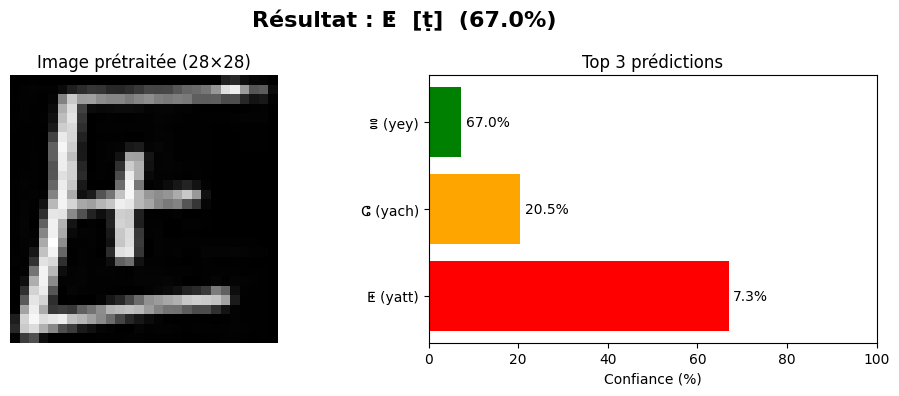


  Caractère Tifinagh : ⵟ
  Translittération   : ṭ
  Label AMHCD        : yatt
  Confiance          : 66.98%

  Top 3 :
    1. ⵟ [ṭ] (yatt) → 66.98%
    2. ⵛ [c] (yach) → 20.50%
    3. ⴻ [ə] (yey) → 7.27%



In [39]:
import os

image_path = "../test/test1.png"  # Remplace par le chemin de ton image

# Vérification avant d'appeler
if not os.path.exists(image_path):
    print(f" Fichier introuvable : {image_path}")
    print(f"   Dossier actuel : {os.getcwd()}")
    print(f"   Fichiers dans test/ :")
    if os.path.exists("test"):
        for f in os.listdir("test"):
            print(f"     - {f}")
    else:
        print("     Dossier test/ n'existe pas")
else:
    print(f"✓ Fichier trouvé : {image_path}")
    # ── Appel de la fonction ──────────────────────────────────
    label, unicode_char, confiance = afficher_resultat(
        image_path, model, class_names
    )
